# Notebook 2 - Arc Calibration

In this notebook, we're extracting spectra from the arc frames. This is not an essential step in the process as we end up using the spectra themselves to calculate the wavelength solution (convert from pixel number to wavelength in Angstroms).

However, it is helpful for a ball park estimate and to help with identifying spectral lines in the stellar spectra.

In [1]:
%matplotlib inline

If wanting to interact directly with plots

In [1]:
%matplotlib widget

In [2]:
import sys
sys.path.insert(0, '/Users/u2257755/Documents/Tiberius/Tiberius/src')

Load in necessary modules.

In [3]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import peakutils
from scipy import stats,optimize,interpolate
import pickle
import reduction_utils.wavelength_calibration as wc

Again, we're going to use example data of WASP-168b.

In [4]:
parent_direc = '/Users/u2257755/Library/CloudStorage/OneDrive-UniversityofWarwick/LRG_BEASTS/WASP-168/2023-02-19/reduction_3_wide_test_fixed_36/'

# Load in stellar spectra
s1 = pickle.load(open(parent_direc+'pickled_objects/star1_flux_cleaned.pickle','rb'))
s2 = pickle.load(open(parent_direc+'pickled_objects/star2_flux_cleaned.pickle','rb'))

# Load in x positions of traces, so that we can extract the arc spectra at the same locations as the stars
trace1 = pickle.load(open(parent_direc+'pickled_objects/x_positions_1.pickle','rb'))
trace2 = pickle.load(open(parent_direc+'pickled_objects/x_positions_2.pickle','rb'))

Now we load in an arc frame, which we find from the run log. Note that we often have arc frames with different exposure times. The longer exposures are helpful to pick out the bluer lines which are lower S/N. In those cases, we load in 2 arc frames, 1 with a longer exposure and 1 with a shorted exposure. 

In this example, we only have a single arc frame.

In [6]:
# load in the frame
arc_fits = fits.open('/Users/u2257755/Library/CloudStorage/OneDrive-UniversityofWarwick/LRG_BEASTS/WASP-168/2023-02-19/master_arc.fits')

# extract data from relevant fits extension
arc = arc_fits[0].data

nframes = len(s1)
row_min = 50
row_max = 1011
rows = np.arange(row_min,row_max)
nrows = len(s1[0])

arc = arc.astype(float)

print(np.shape(arc))


(1030, 1030)


Now plot the stellar positions overlaid on the arc frame. We use the locations of the reference frame (nframes//2).

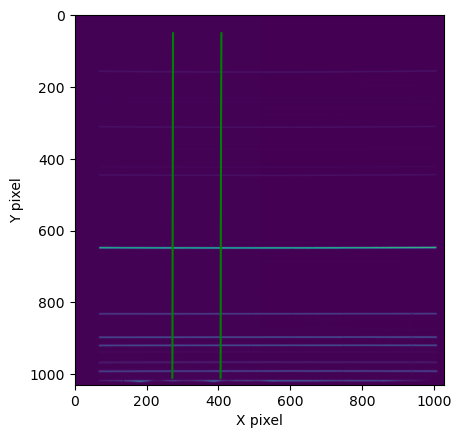

In [7]:
plt.figure()
plt.imshow(arc)
plt.plot(trace1[nframes//2],rows,color='g')
plt.plot(trace2[nframes//2],rows,color='g')
plt.ylabel('Y pixel')
plt.xlabel('X pixel')
plt.show()

Now let's extract the arc data at the location of the 2 traces whilst taking into account the fact that the trace starts from row 300 and ends at row 1670.

In [8]:
slice_arc_1 = []; slice_arc_2 = []

for i, r in enumerate(rows):
    row = arc[r]
    slice_arc_1.append(row[int(trace1[nframes//2][i])])
    slice_arc_2.append(row[int(trace2[nframes//2][i])])
       
slice_arc_1 = np.array(slice_arc_1)
slice_arc_2 = np.array(slice_arc_2)

print(np.shape(rows))


(961,)


Now let's plot the arcs extracted at these locations

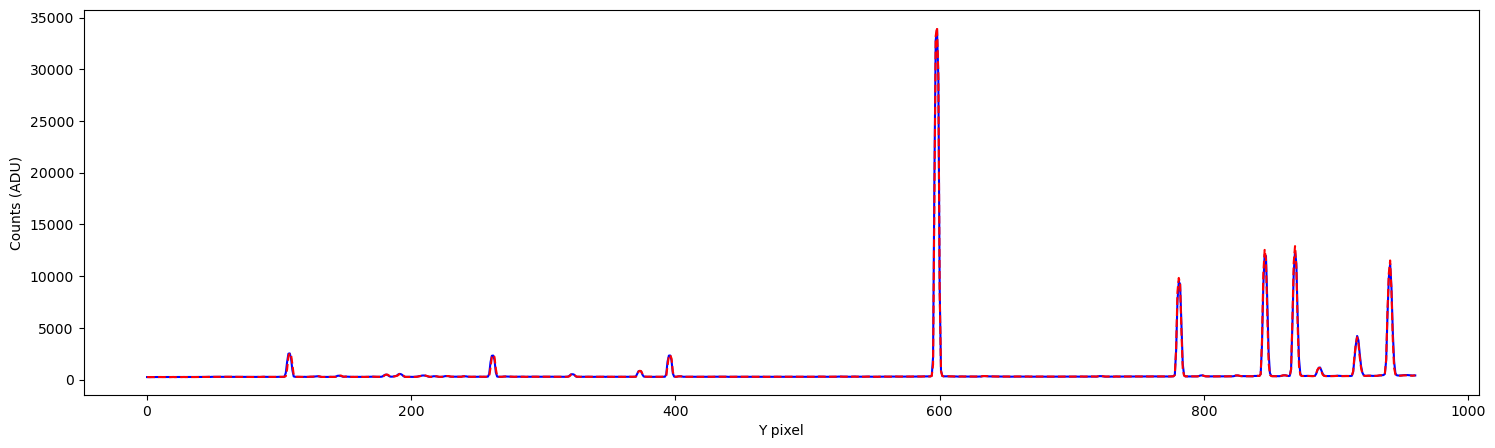

In [9]:
plt.figure(figsize=(18, 5))
plt.plot(slice_arc_1,color='b')
plt.plot(slice_arc_2,'r--')
plt.xlabel('Y pixel')
plt.ylabel('Counts (ADU)')
plt.show()

Just extend the range so we can double check all the He and Ar lines....

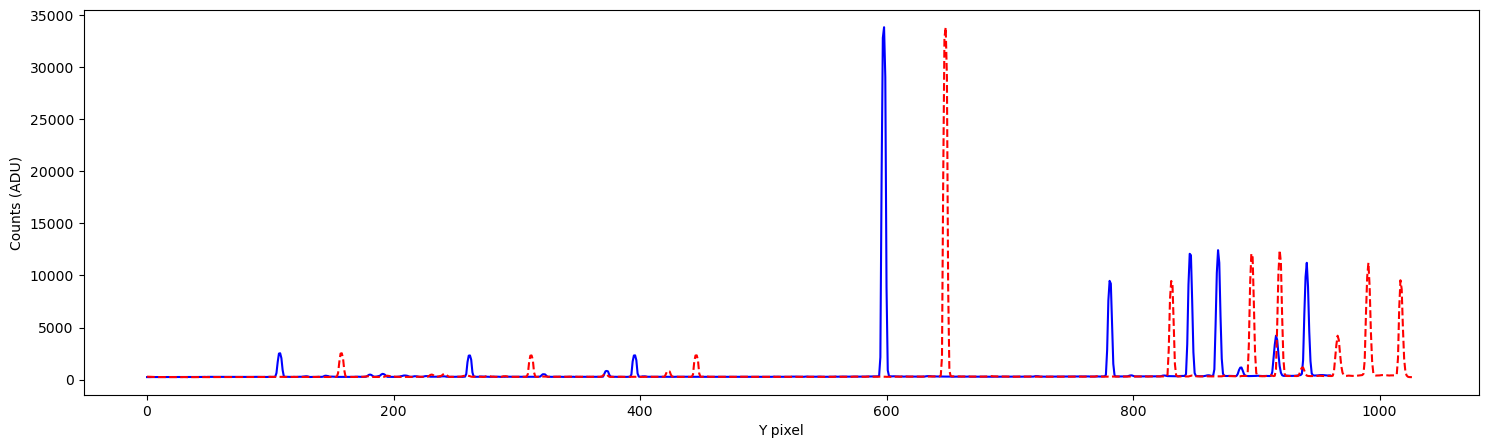

In [11]:
n_target = 1030
n_pad = n_target - trace1.shape[1]
trace1_padded = np.pad(trace1, ((0, 0), (0, n_pad)), mode='edge')

row_min_padded = 0
row_max_padded = 1030
rows_padded = np.arange(row_min_padded,row_max_padded)
nrows_padded = len(s1[0])

slice_arc_1_padded = []

for i, r in enumerate(rows_padded):
    row_padded = arc[r]
    slice_arc_1_padded.append(row_padded[int(trace1_padded[nframes//2][i])])
       
slice_arc_1_padded = np.array(slice_arc_1_padded)

plt.figure(figsize=(18, 5))
plt.plot(slice_arc_1,color='b')
plt.plot(slice_arc_1_padded,'r--')
plt.xlabel('Y pixel')
plt.ylabel('Counts (ADU)')
plt.show()


And find the locations of these features, using the peakutils module which needs to be installed via:
_pip install peakutils_

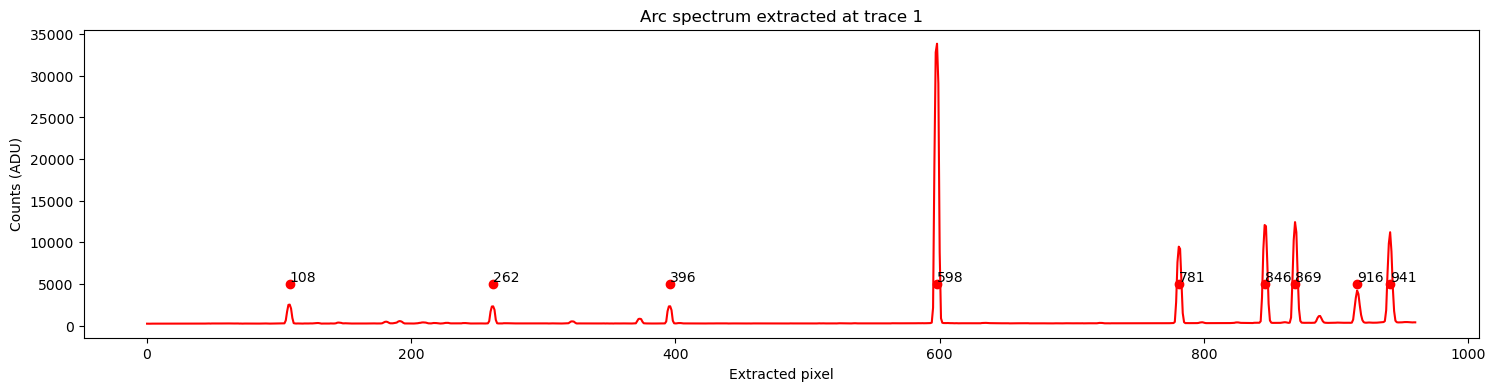

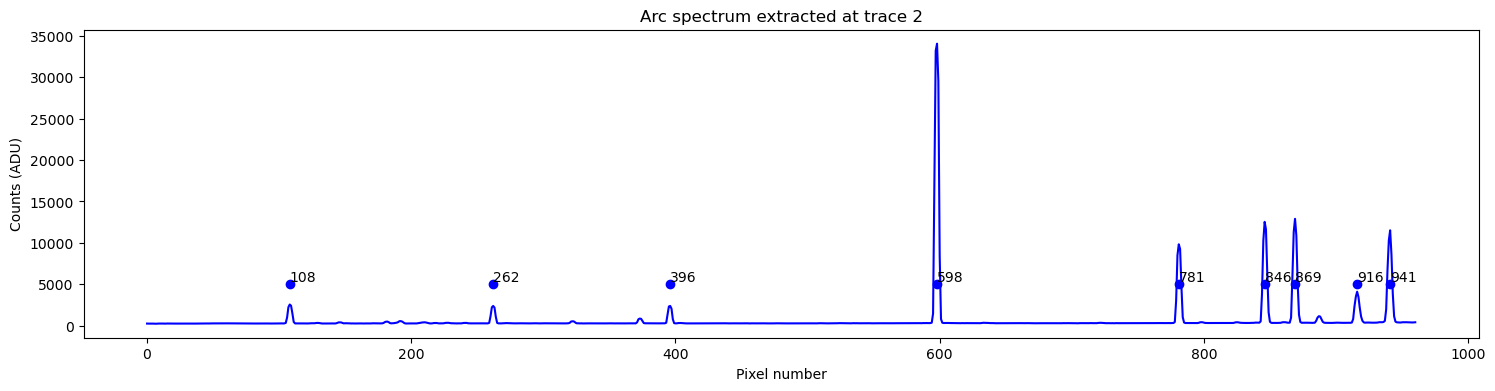

In [12]:
peaks_1 = peakutils.indexes(slice_arc_1.astype(int),thres=0.05,min_dist=10)
plt.figure(figsize=(18, 4))
plt.plot(np.arange(nrows), slice_arc_1, color='r')
plt.scatter(peaks_1, [5000]*len(peaks_1), color='r')

for i in peaks_1:
    plt.text(i, 5010, str(i), rotation='horizontal', verticalalignment='bottom')

plt.ylabel('Counts (ADU)')
plt.xlabel('Extracted pixel')
plt.title('Arc spectrum extracted at trace 1')
plt.show()

peaks_2 = peakutils.indexes(slice_arc_2.astype(int),thres=0.05,min_dist=10)
plt.figure(figsize=(18, 4))
plt.plot(np.arange(nrows), slice_arc_2, color='b')
plt.scatter(peaks_2, [5000]*len(peaks_2), color='b')

for i in peaks_2:
    plt.text(i, 5010, str(i), rotation='horizontal', verticalalignment='bottom')

plt.xlabel('Pixel number')        
plt.ylabel('Counts (ADU)')
plt.title('Arc spectrum extracted at trace 2')
plt.show()

Now using the above positions of the peaks we compare to the EFOSC calibration manual (reduction_utils/EFOSC_utils/HeAr_Gr11.pdf) to find the corresponding wavelength for each. You will need to zoom-in significantly.

For *ACAM*:
The plots above are given on the same x axis and scale as the graphs on pages 10-12 in the ACAM manual (unwindowed pixels). The peaks are annotated in the ACAM manual in units of Angstroms. The peaks in this notebook are annotated in windowed pixels, hence the offset with the x axis. What you need to do is match the peaks from the notebook, using the x axis, to the peaks in the manual. Then you record the numbers from the notebook, in windowed pixels, and match them to the numbers in Angstroms from the manual.

You will find some peaks that are either in the notebook but not the manual and vice versa. Don't worry about these peaks. As long as you have 15-20 matched peaks spanning the full wavelength range, this will be good enough.

You will know if something doesn't look right as a fit using a quadratic polynomial (wc.calc_wvl_solution) will lead to large outliers. You would then need to double check those outliers.

The above spectrum looks like it is a CuNe only spectrum. Now we assign each measured pixel to the wavelength.

For *EFOSC*:
Can just use reduction_utils/EFOSC_utils/HeAr_Gr11.pdf. Just match the peaks to the figure shown. The reason for the plot before to see which other emissions might not be seen as we have 'cropped' along the trace.

Do this all for both traces. We can see below they are very similar anyway. 

In this case, the stars are very close together and there is little difference in the 2 pixel locations of the peaks. We can therefore use the wavelength solution from the first star. This is OK since this is not our final wavelength solution and we will also be resampling the spectra onto the same wavelength array.

However, this is not always true and in some cases a second arc solution may be needed.

In [13]:
# this is my version of the lines from the above plot and the Grism#11 
lines1 = {3888.6:108,4471.5:262,5015.7:396,5875.6:598,6678.1:781,6965.4:846,7065.2:869,7384:941}

all_pixels_1 = np.array(sorted(lines1.values()))
all_wvls_1 = np.array(sorted(lines1.keys()))

# this is my version of the lines from the above plot and the Grism#11 
lines2 = {3888.6:108,4471.5:262,5015.7:396,5875.6:598,6678.1:781,6965.4:846,7065.2:869,7384:941}

all_pixels_2 = np.array(sorted(lines2.values()))
all_wvls_2 = np.array(sorted(lines2.keys()))

Now using the above wavelengths and pixel positions let's fit a second order polynomial. Sometimes we need a higher order (not normally > 4) but here 2nd is fine.

Help on function calc_wvl_solution in module reduction_utils.wavelength_calibration:

calc_wvl_solution(pixel_values, line_wvls, poly_order, stellar_spectrum, verbose=True, refit_clip=None)
    The function that takes the measured locations of absorption lines, in pixels, and fits a polynomial to these to calculate the wavlength solution (in Angstroms).
    
    Inputs:
    pixel_values - the location of the absorption lines in pixels
    line_wvls - the wavelengths (in A) that these absorption lines correspond to
    poly_order - the order of the polynomial used to generate the wavelength solution
    stellar_spectrum - the 1D reference stellar spectrum, used for plotting purposes
    refit_clip - refit the polynomial after clipping outliers from the first fit? Set this to the number of standard deviations at which to clip.
    
    Returns:
    np.array(wvl_solution) - the wavelength solution
    poly - the polynomial used to generate the wavelength solution



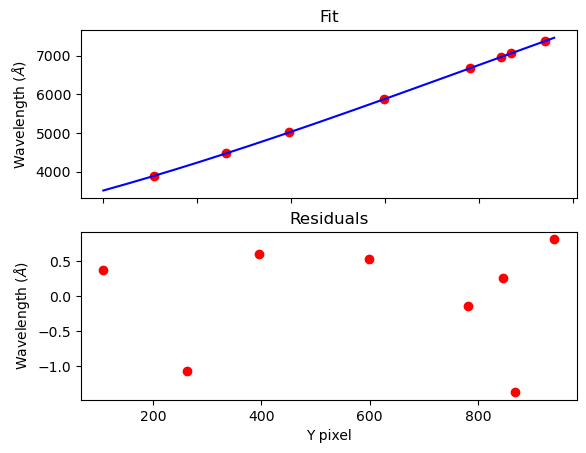

RMS residuals = 0.752556


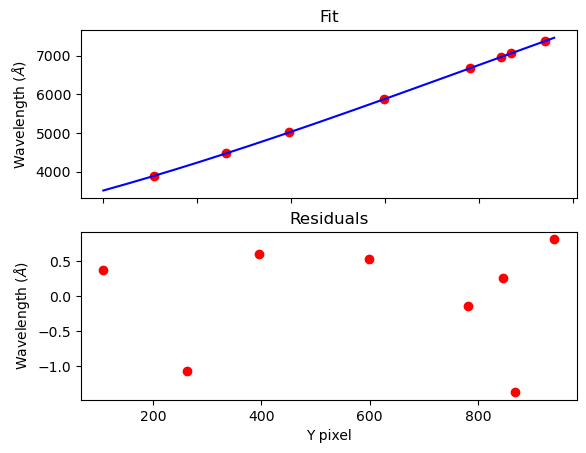

RMS residuals = 0.752556


In [14]:
help(wc.calc_wvl_solution)

wvl_1,poly_1,*rest = wc.calc_wvl_solution(pixel_values = all_pixels_1, line_wvls = all_wvls_1, 
                                          poly_order = 3, 
                                          stellar_spectrum = s1[nframes//2])

wvl_2,poly_2,*rest = wc.calc_wvl_solution(pixel_values = all_pixels_2, line_wvls = all_wvls_2, 
                                          poly_order = 3, 
                                          stellar_spectrum = s2[nframes//2])

Let's check how the solution from the arcs fits with the target's spectrum

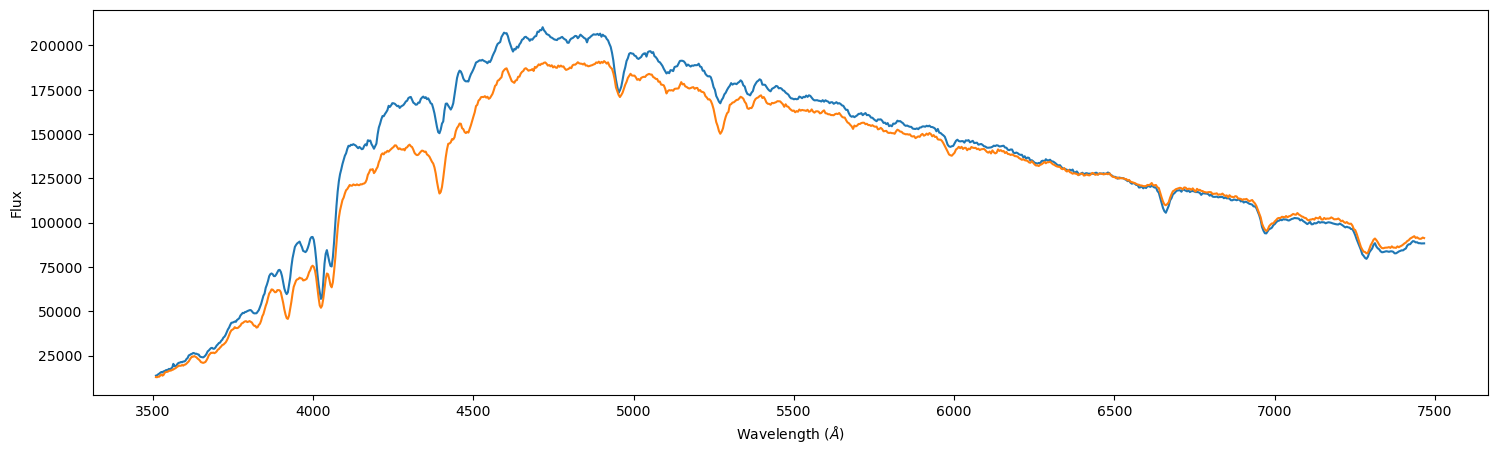

In [15]:
plt.figure(figsize=(18, 5))
plt.plot(wvl_1,s1[nframes//2])
plt.plot(wvl_2,s2[nframes//2])
plt.xlabel('Wavelength ($\AA$)')
plt.ylabel('Flux')
plt.show()

Looks pretty close!

Now save the wavelength arc solution (note this commented for the example).

In [16]:
pickle.dump(wvl_1,open(parent_direc+'pickled_objects/arc_solution_trace1.pickle','wb'))
pickle.dump(wvl_2,open(parent_direc+'pickled_objects/arc_solution_trace2.pickle','wb'))

We're now done and can move to notebook 3.